Question 3)

In [ ]:
import numpy as np

# data is = (x1, x2, x3, label)
# +1 for positive, -1 for negative
data = [
    (2, 2, 3, 1), (3, 3, 2, 1), (1, 2, 3, 1), (1, 4, 1, 1), (4, 4, 4, 1), (2, 2, 2, 1),
    (3, 3, 1, -1), (1, 1, 1, -1), (3, 2, 2, -1), (0, 4, 2, -1), (4, 0, 0, -1), (0, 0, 3, -1)]

#decision boundary
w = np.array([3, 2, 4])
b = -18
norm_w = np.linalg.norm(w)

print(f"Point | Margin | 0-1 | Hinge | Squared")
print("-" * 50)

for x1, x2, x3, y in data:
    x = np.array([x1, x2, x3])

    #raw output/score
    f_x = np.dot(w, x) + b

    #geometric margin
    margin = abs(f_x) / norm_w

    #0-1 loss, prediction is positive if score >=0, else negative
    pred = 1 if f_x >= 0 else -1
    zero_one_loss = 1 if pred != y else 0

    hinge_loss = max(0, 1 - y * f_x)

    squared_loss = (y - f_x)**2

    point_str = f"({x1},{x2},{x3}){'+' if y==1 else '-'}"
    print(f"{point_str} | {margin:5.3f} | {zero_one_loss} | {hinge_loss:<5.1f} | {squared_loss:<5.1f}")

Point | Margin | 0-1 | Hinge | Squared
--------------------------------------------------
(2,2,3)+ | 0.743 | 0 | 0.0   | 9.0  
(3,3,2)+ | 0.928 | 0 | 0.0   | 16.0 
(1,2,3)+ | 0.186 | 0 | 0.0   | 0.0  
(1,4,1)+ | 0.557 | 1 | 4.0   | 16.0 
(4,4,4)+ | 3.343 | 0 | 0.0   | 289.0
(2,2,2)+ | 0.000 | 0 | 1.0   | 1.0  
(3,3,1)- | 0.186 | 1 | 2.0   | 4.0  
(1,1,1)- | 1.671 | 0 | 0.0   | 64.0 
(3,2,2)- | 0.557 | 1 | 4.0   | 16.0 
(0,4,2)- | 0.371 | 0 | 0.0   | 1.0  
(4,0,0)- | 1.114 | 0 | 0.0   | 25.0 
(0,0,3)- | 1.114 | 0 | 0.0   | 25.0 


Question 5

In [22]:
import numpy as np

X = np.load('data_X_Q5Q6.npy')
y = np.load('data_y_Q5Q6.npy').reshape(-1, 1)

#hyperparameters
lambda_reg = 1e-6
learning_rate = 0.01
epochs = 1000
n, d = X.shape

def get_closed_form(X, y, lam=0):
    I = np.eye(X.shape[1])
    return np.linalg.inv(X.T @ X + n * lam * I) @ X.T @ y

def gradient_descent(X, y, lam=0, lr=0.01, steps=1000):
    w = np.zeros((X.shape[1], 1))
    for _ in range(steps):
        grad = (1/n) * X.T @ (X @ w - y) + lam * w
        w -= lr * grad
    return w

def stochastic_gradient_descent(X, y, lam=0, lr=0.01, steps=1000):
    w = np.zeros((X.shape[1], 1))
    for _ in range(steps):
        for i in range(n):
            xi = X[i:i+1]
            yi = y[i:i+1]
            grad = xi.T @ (xi @ w - yi) + lam * w
            w -= lr * grad
    return w

#l2 norm distance
def l2_dist(w1, w2):
    return np.linalg.norm(w1 - w2)

#RUN The code
results = {}

for mode, lam in [("LSQR", 0), ("Ridge", lambda_reg)]:
    w_cf = get_closed_form(X, y, lam)
    w_gd = gradient_descent(X, y, lam, learning_rate, epochs)
    w_sgd = stochastic_gradient_descent(X, y, lam, learning_rate, epochs)

    results[mode] = {"GD vs CF": l2_dist(w_gd, w_cf),"SGD vs CF": l2_dist(w_sgd, w_cf),
        "GD vs SGD": l2_dist(w_gd, w_sgd)}

#print results
for reg_type, dist in results.items():
    print(f"Results")
    for comparison, dist in dist.items():
        print(f"{comparison}: {dist}")

Results
GD vs CF: 6.853557194060987
SGD vs CF: 0.29971185428771885
GD vs SGD: 6.854057274226817
Results
GD vs CF: 6.845659595130013
SGD vs CF: 0.2995774101130361
GD vs SGD: 6.846227507437355


Question 6

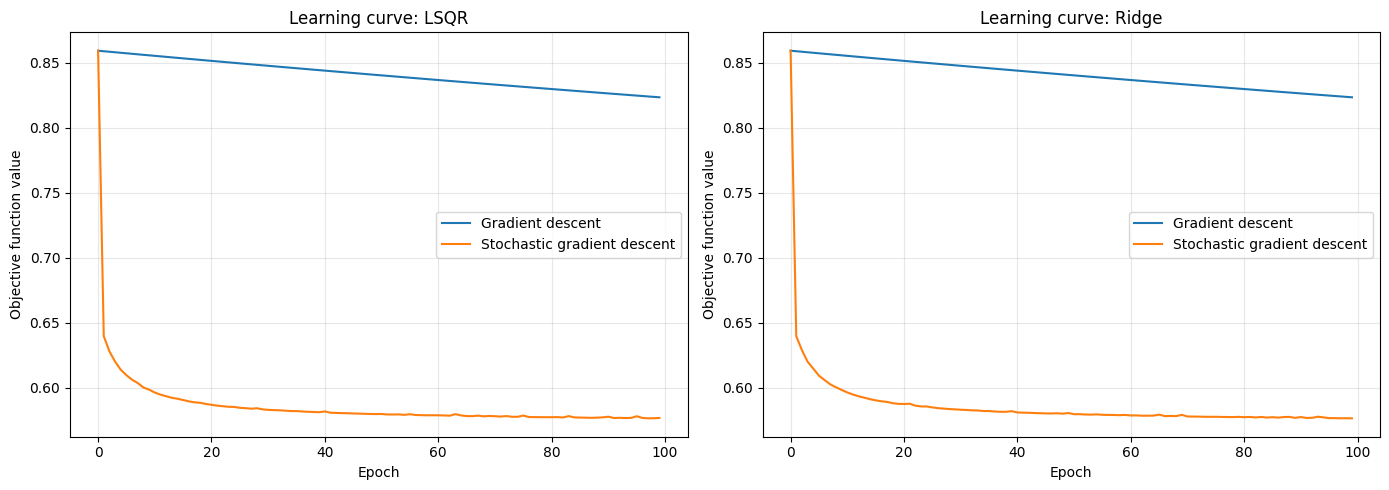

In [26]:
import numpy as np
import matplotlib.pyplot as plt


X = np.load('data_X_Q5Q6.npy')
y = np.load('data_y_Q5Q6.npy').reshape(-1, 1)
n, d = X.shape
lambda_reg = 1e-6

def compute_loss(X, y, w, lam):
    mse = (1 / (2 * n)) * np.sum((X @ w - y)**2)
    reg = (lam / 2) * np.sum(w**2)
    return mse + reg

#gradient descent
def gd_with_history(X, y, lam=0, lr=0.01, steps=500):
    w = np.zeros((d, 1))
    history = []
    for _ in range(steps):
        history.append(compute_loss(X, y, w, lam))
        grad = (1/n) * X.T @ (X @ w - y) + lam * w
        w -= lr * grad
    return history

#stochastic gradient descent
def sgd_with_history(X, y, lam=0, lr=0.01, steps=500):
    w = np.zeros((d, 1))
    history = []
    for _ in range(steps):

        #calculate loss for all data set before epoch starts
        history.append(compute_loss(X, y, w, lam))

        #shuffle indices, to ensure that in every epoch the model face random data points
        indices = np.random.permutation(n)
        for i in indices:
            xi = X[i:i+1]
            yi = y[i:i+1]
            # stochastic gradient for one point
            grad = xi.T @ (xi @ w - yi) + lam * w
            w -= lr * grad
    return history

lr = 0.001 #learning rate
steps = 100

results = {"LSQR": {"GD": gd_with_history(X, y, lam=0, lr=lr, steps=steps),
        "SGD": sgd_with_history(X, y, lam=0, lr=lr, steps=steps)},
    "Ridge": {"GD": gd_with_history(X, y, lam=lambda_reg, lr=lr, steps=steps),
        "SGD": sgd_with_history(X, y, lam=lambda_reg, lr=lr, steps=steps)}}

#plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for i, (mode, data) in enumerate(results.items()):

    ax[i].plot(data["GD"], label='Gradient descent')
    ax[i].plot(data["SGD"], label='Stochastic gradient descent')
    ax[i].set_title(f'Learning curve: {mode}')
    ax[i].set_xlabel('Epoch')
    ax[i].legend()
    ax[i].set_ylabel('Objective function value')

    ax[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Question 7

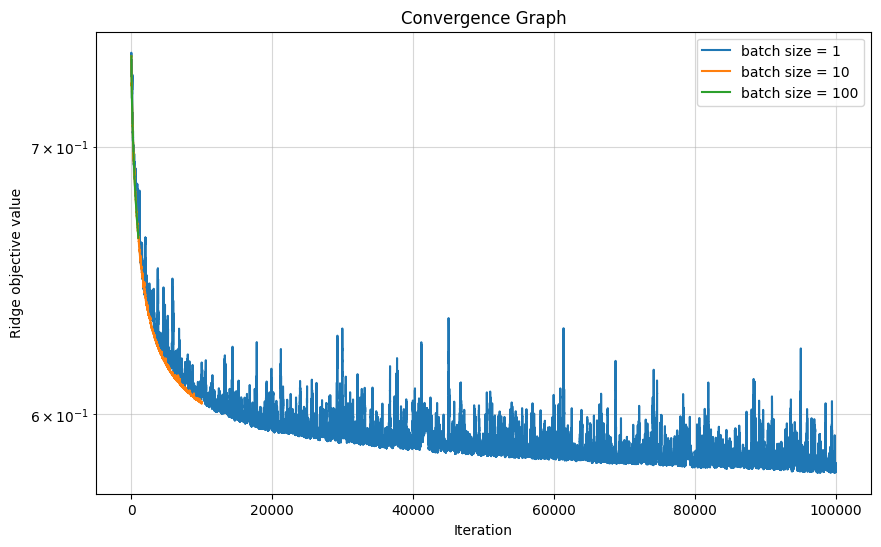

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def load_data():
    X = np.load('data_X_Q7.npy')
    y = np.load('data_y_Q7.npy').reshape(-1, 1)
    return X, y

def compute_objective(X, y, w, lam):
    n = X.shape[0]
    mse = np.sum((X @ w - y)**2) / (2 * n)
    reg = (lam / 2) * np.sum(w**2)
    return mse + reg

def batched_sgd(X, y, batch_size, lam, lr, epochs):
    n, d = X.shape
    w = np.zeros((d, 1))
    loss_history = []

    for epoch in range(epochs):
        # Shuffle indices, to make sure truly random
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, n, batch_size):
            # before update, record the full objective
            loss_history.append(compute_objective(X, y, w, lam))


            X_batch = X_shuffled[i : i + batch_size]
            y_batch = y_shuffled[i : i + batch_size]
            m = X_batch.shape[0]

            #gradient for the mini-batch
            grad = (X_batch.T @ (X_batch @ w - y_batch)) / m + lam * w

            #update weights
            w -= lr * grad

    return w, loss_history

# Parameters
X, y = load_data()
lambda_reg = 1e-6
learning_rate = 0.01
epochs = 20
batch_sizes = [1, 10, 100]


plt.figure(figsize=(10, 6))
for bs in batch_sizes:
    _, history = batched_sgd(X, y, bs, lambda_reg, learning_rate, epochs)
    plt.plot(history, label=f'batch size = {bs}')

plt.title('Convergence Graph')
plt.xlabel('Iteration')
plt.ylabel('Ridge objective value')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.savefig('ridge_batched_sgd_curves.png')